<a href="https://colab.research.google.com/github/HCI-hope/HCI-Models/blob/main/Implementing_LSTM%26BPNN(with_novelty).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

Mounted at /content/drive
 Libraries loaded!
🚀  4-Direction EEG Classifier  —  Improved Models

Found 12 Excel files

   Cheby_ARROW_Right.xlsx                        → Right      (19 windows)
   Cheby_WORD_Backword.xlsx                      → Backward   (19 windows)
   Cheby_LETTER_Backward.xlsx                    → Backward   (19 windows)
   Cheby_ARROW_Forward.xlsx                      → Forward    (19 windows)
   Cheby_LETTER_Forward.xlsx                     → Forward    (19 windows)
   Cheby_ARROW_Left.xlsx                         → Left       (19 windows)
   Cheby_WORD_Right.xlsx                         → Right      (19 windows)
   Cheby_WORD_Forward.xlsx                       → Forward    (19 windows)
   Cheby_ARROW_Backward.xlsx                     → Backward   (19 windows)
   Cheby_LETTER_Right.xlsx                       → Right      (19 windows)
   Cheby_WORD_Left.xlsx                          → Left       (19 windows)
   Cheby_LETTER_Left.xlsx                        → Left  

Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 1000, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 1000, 256) │    134,144 │ eeg_input[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_1                │ (None, 1000, 256) │        512 │ bilstm_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 1000, 256) │          0 │ ln_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 1000, 128) │    164,352 │ drop_1[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_2                │ (None, 1000, 128) │        256 │ bilstm_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 1000, 128) │          0 │ ln_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mhsa                │ (None, 1000, 128) │     66,048 │ drop_2[0][0],     │
│ (MultiHeadAttentio… │                   │            │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_attn             │ (None, 1000, 128) │        256 │ mhsa[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 1000, 128) │          0 │ drop_2[0][0],     │
│                     │                   │            │ ln_attn[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_residual         │ (None, 1000, 128) │        256 │ residual[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 128)       │          0 │ ln_residual[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_dense            │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_dense          │ (None, 128)       │          0 │ bn_dense[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ drop_dense[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_dense2         │ (None, 64)        │          0 │ dense_2[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        260 │ drop_dense2[0][0] │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 391,364 (1.49 MB)

 Trainable params: 391,108 (1.49 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 80s 14s/step - accuracy: 0.2610 - loss: 1.9954 - val_accuracy: 0.1622 - val_loss: 1.7901 - learning_rate: 5.0000e-04
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 65s 12s/step - accuracy: 0.2985 - loss: 1.8132 - val_accuracy: 0.1622 - val_loss: 1.8047 - learning_rate: 5.0000e-04
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 81s 13s/step - accuracy: 0.3176 - loss: 1.6856 - val_accuracy: 0.1622 - val_loss: 1.8139 - learning_rate: 5.0000e-04
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 84s 14s/step - accuracy: 0.2547 - loss: 1.7462 - val_accuracy: 0.1622 - val_loss: 1.8482 - learning_rate: 5.0000e-04
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 75s 12s/step - accuracy: 0.2632 - loss: 1.5896 - val_accuracy: 0.1622 - val_loss: 1.8564 - learning_rate: 5.0000e-04
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 87s 13s/step - accuracy: 0.3204 - loss: 1.6044 - val_accuracy: 0.1622 - val_loss: 1.8536 - learning_rate: 5.0000e-04
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 75s 11s/step - accuracy: 0.3214 - loss:

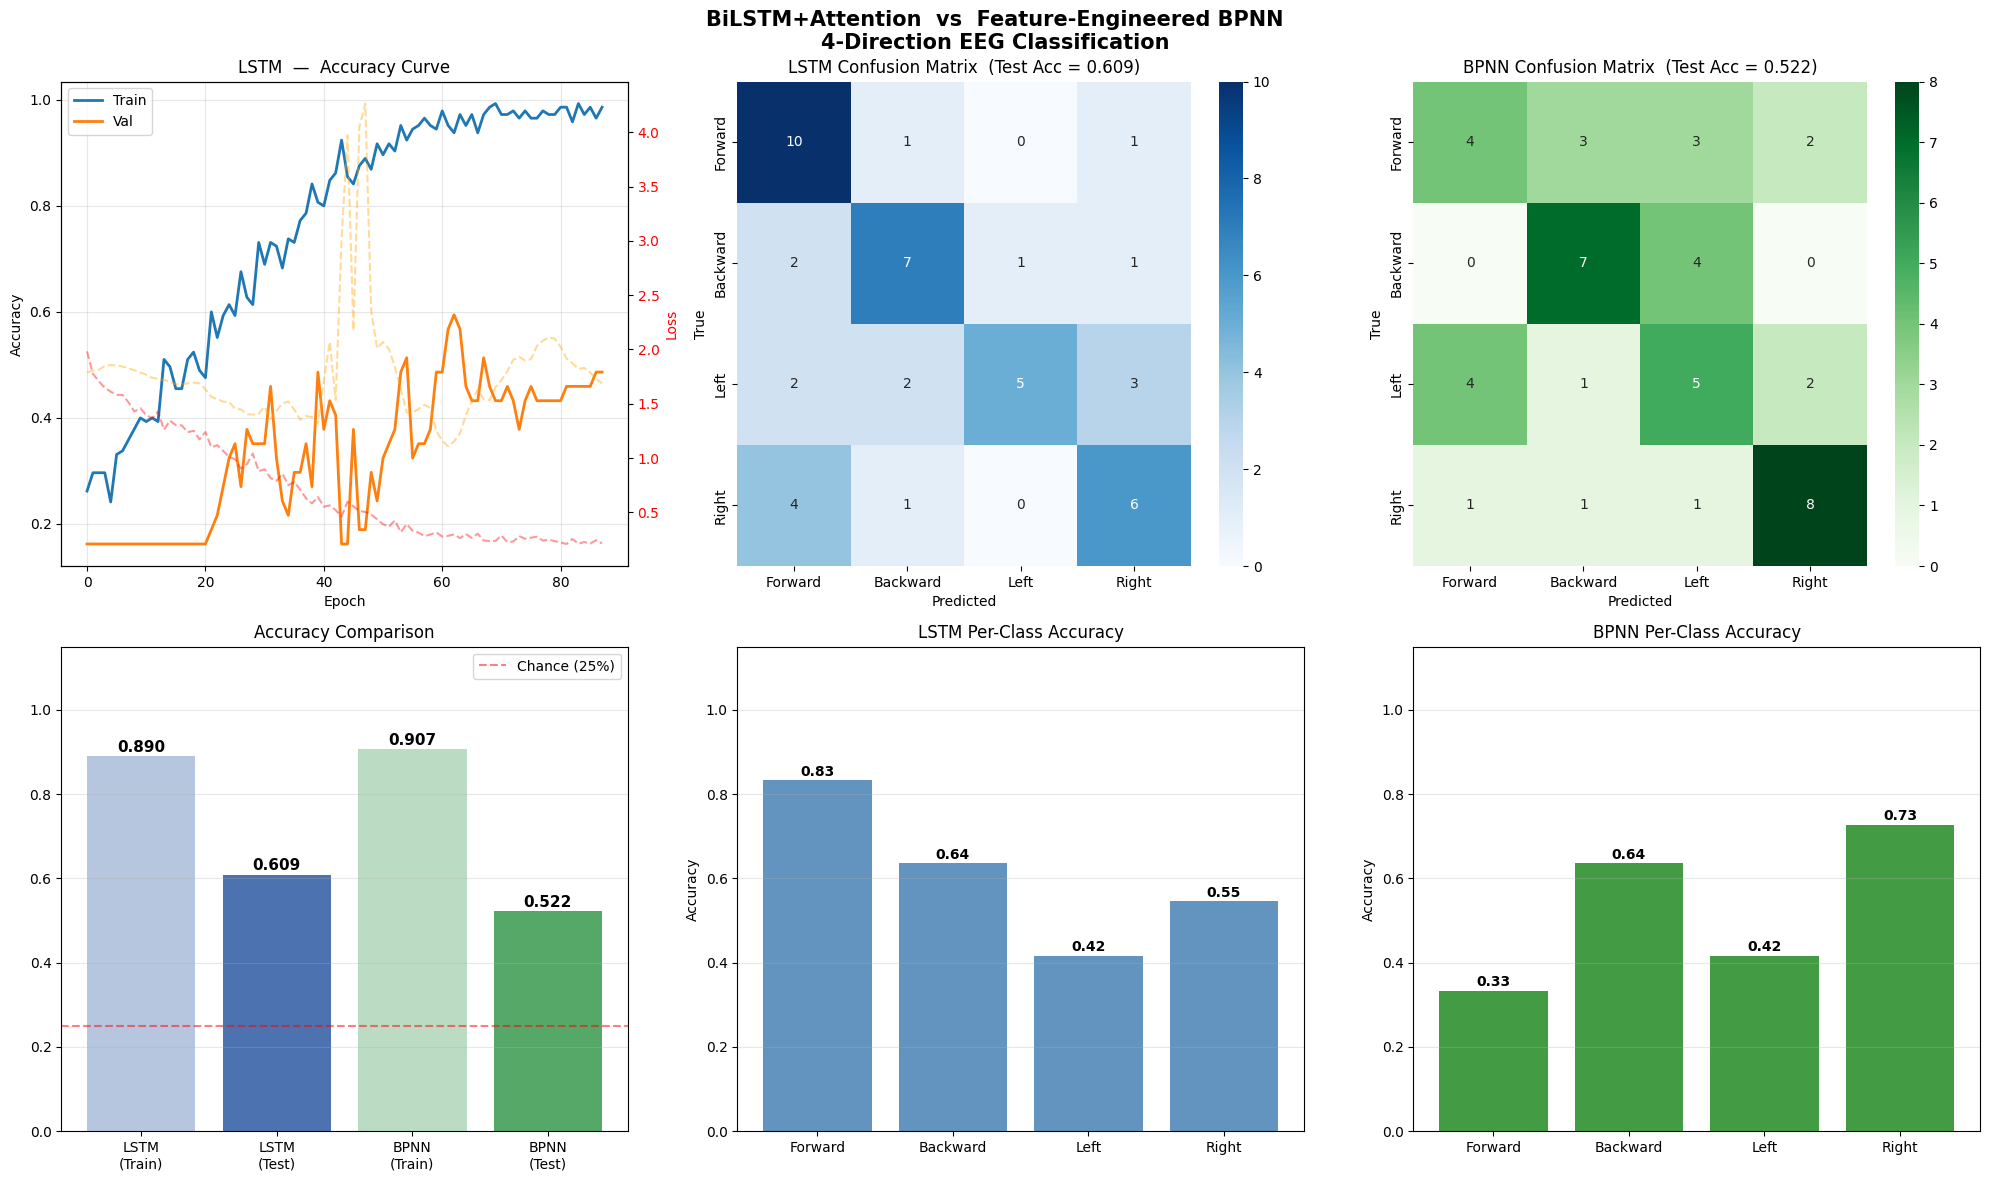


  Figure saved → /content/drive/MyDrive/improved_4direction_results.png

════════════════════════════════════════════════════════════
    FINAL SUMMARY
════════════════════════════════════════════════════════════
  LSTM  (BiLSTM+Attn) — Train: 0.8901  Test: 0.6087
  BPNN  (Feat+MLP)    — Train: 0.9066  Test: 0.5217
════════════════════════════════════════════════════════════

 Models saved:
    lstm_bilstm_attn_4dir.keras
    bpnn_feat_4dir.pkl
    scaler_feat_4dir.pkl
    improved_4direction_results.png


In [2]:
"""
LSTM & BPNN — 4-Direction EEG Classification (IMPROVED)
=========================================================
LSTM  : Bidirectional LSTM + Multi-Head Self-Attention + Residual Connection
BPNN  : Statistical + Frequency-Domain Feature Extraction → Deep MLP

Why these changes?
  Original LSTM  → Unidirectional, no attention, ~24% test → underfitting
  Original BPNN  → Raw flattened windows, ~17% test, 86% train → overfitting
  Fix LSTM       → BiLSTM sees past & future context; attention focuses on
                   informative time-steps; residual helps gradient flow
  Fix BPNN       → Compact engineered features (stat + FFT) replace 2000-dim
                   flat input, eliminating the main cause of BPNN overfitting
"""

# ===== GOOGLE COLAB + GOOGLE DRIVE SETUP =====
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import joblib
import warnings
warnings.filterwarnings('ignore')

from scipy import signal as scipy_signal
from scipy.stats import skew, kurtosis

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, BatchNormalization,
    Bidirectional, MultiHeadAttention, LayerNormalization,
    GlobalAveragePooling1D, Add, Activation
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
import seaborn as sns

print(" Libraries loaded!")

# ──────────────────────────────────────────────────────────────────────────────
#  CONFIGURATION
# ──────────────────────────────────────────────────────────────────────────────
FOLDERS_PATH = '/content/drive/MyDrive/Human Computer Interface (HCI)/Processed_Filtered_Data/Subject1_Chebyshev_Filtered'
CHANNELS     = [7, 9]
WINDOW_SIZE  = 1000
OVERLAP      = 0.5       # 50 % overlap
TEST_SIZE    = 0.2
RANDOM_SEED  = 42
FS           = 256       # EEG sampling frequency in Hz (adjust if different)

DIRECTION_MAP = {
    'forward':  0,
    'backward': 1,
    'backword': 1,   # typo variant
    'left':     2,
    'right':    3,
}
CLASS_NAMES = {0: 'Forward', 1: 'Backward', 2: 'Left', 3: 'Right'}
NUM_CLASSES = 4


# ──────────────────────────────────────────────────────────────────────────────
#  DATA LOADING  (unchanged from original)
# ──────────────────────────────────────────────────────────────────────────────
def get_direction_label(filename):
    name_lower = filename.lower()
    for direction, label in DIRECTION_MAP.items():
        if direction in name_lower:
            return label
    return None


def load_single_file(file_path, label):
    df   = pd.read_excel(file_path)
    data = df.iloc[:, CHANNELS].values.T          # (n_channels, n_samples)

    step = int(WINDOW_SIZE * (1 - OVERLAP))
    X, y = [], []
    for i in range(0, data.shape[1] - WINDOW_SIZE, step):
        window = data[:, i:i + WINDOW_SIZE]
        if np.isnan(window).any() or np.isinf(window).any():
            continue
        X.append(window)
        y.append(label)
    return np.array(X), np.array(y)


def load_all_folders_data(base_path):
    all_X, all_y = [], []
    excel_files = list(set(
        glob.glob(os.path.join(base_path, '**', '*.xlsx'), recursive=True) +
        glob.glob(os.path.join(base_path, '*.xlsx'))
    ))
    print(f"Found {len(excel_files)} Excel files\n")

    label_counts = {i: 0 for i in range(NUM_CLASSES)}
    skipped = []

    for file_path in excel_files:
        filename = os.path.basename(file_path)
        label    = get_direction_label(filename)
        if label is None:
            skipped.append(filename)
            continue
        try:
            X_w, y_w = load_single_file(file_path, label)
            all_X.extend(X_w)
            all_y.extend(y_w)
            label_counts[label] += len(X_w)
            print(f"   {filename:45s} → {CLASS_NAMES[label]:10s} ({len(X_w)} windows)")
        except Exception as e:
            print(f"   Error loading {filename}: {e}")

    if skipped:
        print(f"\n   Skipped: {skipped}")

    X = np.array(all_X)
    y = np.array(all_y)
    print(f"\nTotal windows: {len(X)}")
    for i, name in CLASS_NAMES.items():
        print(f"   {name:10s}: {label_counts[i]}")
    return X, y


# ──────────────────────────────────────────────────────────────────────────────
#  NOVELTY 1 ▸ BPNN — FEATURE EXTRACTION
#  Root cause of original BPNN overfitting: 2 channels × 1000 samples = 2000-dim
#  flat input. Solution: extract ~40 compact, meaningful features per window.
# ──────────────────────────────────────────────────────────────────────────────
EEG_BANDS = {           # frequency bands (Hz)
    'delta': (0.5, 4),
    'theta': (4,   8),
    'alpha': (8,  13),
    'beta':  (13, 30),
    'gamma': (30, 50),
}

def band_power(channel_data, fs, low, high):
    """Bandpass-filtered signal power using Welch PSD."""
    freqs, psd = scipy_signal.welch(channel_data, fs=fs, nperseg=min(256, len(channel_data)))
    idx = np.logical_and(freqs >= low, freqs <= high)
    return np.trapz(psd[idx], freqs[idx])


def extract_features_single_window(window, fs=FS):
    """
    Extract statistical + frequency-domain features from one window.
    window shape: (n_channels, window_size)

    Per channel:
      - Time domain : mean, std, variance, skewness, kurtosis,
                      RMS, zero-crossing rate, peak-to-peak amplitude,
                      Hjorth mobility, Hjorth complexity
      - Frequency   : power in delta/theta/alpha/beta/gamma bands,
                      dominant frequency, spectral entropy

    Cross-channel:
      - Pearson correlation between channels
    """
    features = []
    n_channels = window.shape[0]
    first_deriv_all = []

    for ch in range(n_channels):
        sig = window[ch]

        # ── Time-domain features ──────────────────────────────────────────
        mean_val   = np.mean(sig)
        std_val    = np.std(sig)
        var_val    = np.var(sig)
        skew_val   = skew(sig)
        kurt_val   = kurtosis(sig)
        rms_val    = np.sqrt(np.mean(sig ** 2))

        # Zero-crossing rate
        zcr = np.sum(np.diff(np.sign(sig)) != 0) / len(sig)

        # Peak-to-peak
        ptp = np.ptp(sig)

        # Hjorth parameters
        d1     = np.diff(sig)
        d2     = np.diff(d1)
        mob    = np.std(d1) / (std_val + 1e-8)
        comp   = (np.std(d2) / (np.std(d1) + 1e-8)) / (mob + 1e-8)

        first_deriv_all.append(d1)

        # ── Frequency-domain features ─────────────────────────────────────
        freqs, psd = scipy_signal.welch(sig, fs=fs, nperseg=min(256, len(sig)))
        total_pow  = np.sum(psd) + 1e-8

        band_powers = []
        for band_name, (lo, hi) in EEG_BANDS.items():
            bp = band_power(sig, fs, lo, hi)
            band_powers.append(bp / total_pow)   # relative band power

        dom_freq = freqs[np.argmax(psd)]

        # Spectral entropy (Shannon)
        psd_norm     = psd / (total_pow)
        spec_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-8))

        ch_features = [
            mean_val, std_val, var_val, skew_val, kurt_val,
            rms_val, zcr, ptp, mob, comp,
            *band_powers, dom_freq, spec_entropy
        ]
        features.extend(ch_features)

    # ── Cross-channel features ────────────────────────────────────────────
    if n_channels >= 2:
        corr = np.corrcoef(window[0], window[1])[0, 1]
        features.append(corr if not np.isnan(corr) else 0.0)

    return np.array(features, dtype=np.float32)


def extract_all_features(X_raw):
    """
    X_raw: (n_samples, n_channels, window_size)
    Returns: (n_samples, n_features)
    """
    print("   Extracting features", end="", flush=True)
    feats = []
    for idx, window in enumerate(X_raw):
        feats.append(extract_features_single_window(window))
        if (idx + 1) % 200 == 0:
            print(".", end="", flush=True)
    print(f" done! Feature vector size: {feats[0].shape[0]}")
    return np.array(feats)


# ──────────────────────────────────────────────────────────────────────────────
#  NOVELTY 1 ▸ BPNN MODEL
#  Deep MLP with:
#    - Engineered features (not raw flat windows)
#    - Stronger L2 + dropout regularisation
#    - Larger architecture but constrained by compact input
# ──────────────────────────────────────────────────────────────────────────────
def train_bpnn(X_train_raw, y_train, X_test_raw, y_test, class_names):
    """
    Train BPNN on engineered features.
    Returns: model, scaler, train_acc, test_acc, y_pred
    """
    print("\n" + "═"*60)
    print("BPNN  —  Feature-Engineered Deep MLP")
    print("═"*60)

    # Feature extraction
    print("  [1/4] Extracting features from training windows...")
    X_train_feat = extract_all_features(X_train_raw)
    print("  [2/4] Extracting features from test windows...")
    X_test_feat  = extract_all_features(X_test_raw)

    # RobustScaler is better than StandardScaler for EEG (outlier-robust)
    scaler = RobustScaler()
    X_train_sc = scaler.fit_transform(X_train_feat)
    X_test_sc  = scaler.transform(X_test_feat)

    print(f"  [3/4] Training MLP on {X_train_sc.shape[0]} samples, "
          f"{X_train_sc.shape[1]} features...")

    bpnn = MLPClassifier(
        # Wider-then-narrower funnel — suited for feature-space inputs
        hidden_layer_sizes=(256, 128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.005,                  # NOVELTY: stronger L2 vs original 0.0001
        batch_size=32,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=3000,
        random_state=RANDOM_SEED,
        early_stopping=True,
        validation_fraction=0.15,     # larger validation slice
        n_iter_no_change=30,          # more patience
        tol=1e-5,
    )

    bpnn.fit(X_train_sc, y_train)

    print("  [4/4] Evaluating...")
    train_acc = accuracy_score(y_train, bpnn.predict(X_train_sc))
    y_pred    = bpnn.predict(X_test_sc)
    test_acc  = accuracy_score(y_test, y_pred)

    print(f"\n  BPNN Train Accuracy : {train_acc:.4f}")
    print(f"   BPNN Test  Accuracy : {test_acc:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=class_names, zero_division=0))

    return bpnn, scaler, train_acc, test_acc, y_pred


# ──────────────────────────────────────────────────────────────────────────────
#  NOVELTY 2 ▸ LSTM MODEL
#  Architecture:
#    Input → BiLSTM(128) → LayerNorm → BiLSTM(64) → Multi-Head Attention
#           → Residual Add → LayerNorm → Dense head → Softmax(4)
#
#  Why each novelty:
#    BiLSTM        : processes sequence in both directions — captures richer
#                    temporal context (EEG signals have bidirectional patterns)
#    Multi-Head    : lets model focus on multiple informative time-steps
#    Attention       simultaneously (e.g. event-onset AND offset)
#    Residual Add  : gradient highway — prevents vanishing gradient in deep net
#    LayerNorm     : more stable than BatchNorm for sequence models
# ──────────────────────────────────────────────────────────────────────────────
def build_bilstm_attention_model(input_shape, num_classes=NUM_CLASSES):
    """
    BiLSTM + Multi-Head Self-Attention + Residual connection.
    input_shape: (time_steps, n_channels) i.e. (1000, 2)
    """
    inp = Input(shape=input_shape, name="eeg_input")

    # ── Block 1: First BiLSTM ────────────────────────────────────────────
    x = Bidirectional(
        LSTM(128, return_sequences=True,
             kernel_regularizer=l2(1e-4),
             recurrent_regularizer=l2(1e-4)),
        name="bilstm_1"
    )(inp)
    x = LayerNormalization(name="ln_1")(x)
    x = Dropout(0.3, name="drop_1")(x)

    # ── Block 2: Second BiLSTM ───────────────────────────────────────────
    x2 = Bidirectional(
        LSTM(64, return_sequences=True,
             kernel_regularizer=l2(1e-4),
             recurrent_regularizer=l2(1e-4)),
        name="bilstm_2"
    )(x)
    x2 = LayerNormalization(name="ln_2")(x2)
    x2 = Dropout(0.3, name="drop_2")(x2)

    # ── NOVELTY: Multi-Head Self-Attention ───────────────────────────────
    # 4 heads, key_dim=32 → focuses on the most discriminative time-steps
    attn_out = MultiHeadAttention(
        num_heads=4, key_dim=32, dropout=0.1, name="mhsa"
    )(x2, x2)                                  # self-attention: Q=K=V=x2
    attn_out = LayerNormalization(name="ln_attn")(attn_out)

    # ── NOVELTY: Residual connection (skip from bilstm_2 output) ────────
    # Requires matching dimensions — project x2 if needed (here same dim 128)
    residual = Add(name="residual")([x2, attn_out])
    residual = LayerNormalization(name="ln_residual")(residual)

    # ── Pool over time axis ──────────────────────────────────────────────
    pooled = GlobalAveragePooling1D(name="gap")(residual)

    # ── Classification head ──────────────────────────────────────────────
    dense = Dense(128, activation='relu',
                  kernel_regularizer=l2(1e-4), name="dense_1")(pooled)
    dense = BatchNormalization(name="bn_dense")(dense)
    dense = Dropout(0.4, name="drop_dense")(dense)

    dense = Dense(64, activation='relu',
                  kernel_regularizer=l2(1e-4), name="dense_2")(dense)
    dense = Dropout(0.3, name="drop_dense2")(dense)

    out = Dense(num_classes, activation='softmax', name="output")(dense)

    model = Model(inputs=inp, outputs=out, name="BiLSTM_Attention")
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def train_lstm(X_train_raw, y_train, X_test_raw, y_test, class_names):
    """
    Train BiLSTM+Attention model.
    X shape: (n_samples, n_channels, window_size)  →  transpose to (n, time, ch)
    Returns: model, history, train_acc, test_acc, y_pred
    """
    print("\n" + "═"*60)
    print(" LSTM  —  Bidirectional LSTM + Multi-Head Attention")
    print("═"*60)

    # Reshape: (batch, channels, time) → (batch, time, channels)
    X_train_lstm = X_train_raw.transpose(0, 2, 1)
    X_test_lstm  = X_test_raw.transpose(0, 2, 1)

    # ── Per-sample channel normalisation (improves convergence for EEG) ──
    # Normalise each training sample independently so amplitude differences
    # between trials don't confuse the model.
    X_train_mean = X_train_lstm.mean(axis=1, keepdims=True)
    X_train_std  = X_train_lstm.std(axis=1, keepdims=True) + 1e-8
    X_train_lstm = (X_train_lstm - X_train_mean) / X_train_std

    X_test_mean  = X_test_lstm.mean(axis=1, keepdims=True)
    X_test_std   = X_test_lstm.std(axis=1, keepdims=True) + 1e-8
    X_test_lstm  = (X_test_lstm - X_test_mean) / X_test_std

    input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2])
    print(f"  Input shape: {input_shape}  (time_steps, channels)")

    model = build_bilstm_attention_model(input_shape)
    model.summary()

    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=25,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', patience=12,
                          factor=0.3, min_lr=1e-7, verbose=1),
        ModelCheckpoint('/content/drive/MyDrive/lstm_bilstm_best.keras',
                        monitor='val_accuracy', save_best_only=True, verbose=0),
    ]

    history = model.fit(
        X_train_lstm, y_train,
        epochs=200,
        batch_size=32,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
    )

    train_acc = model.evaluate(X_train_lstm, y_train, verbose=0)[1]
    test_acc  = model.evaluate(X_test_lstm,  y_test,  verbose=0)[1]
    y_pred    = np.argmax(model.predict(X_test_lstm, verbose=0), axis=1)

    print(f"\n  🏆 LSTM Train Accuracy : {train_acc:.4f}")
    print(f"  🏆 LSTM Test  Accuracy : {test_acc:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=class_names, zero_division=0))

    return model, history, train_acc, test_acc, y_pred


# ──────────────────────────────────────────────────────────────────────────────
#  VISUALISATION
# ──────────────────────────────────────────────────────────────────────────────
def plot_results(history, y_test,
                 y_pred_lstm, lstm_train_acc, lstm_test_acc,
                 y_pred_bpnn, bpnn_train_acc, bpnn_test_acc,
                 class_names):

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('BiLSTM+Attention  vs  Feature-Engineered BPNN\n4-Direction EEG Classification',
                 fontsize=15, fontweight='bold')

    # 1. LSTM training curves
    ax = axes[0, 0]
    ax.plot(history.history['accuracy'],     label='Train', linewidth=2)
    ax.plot(history.history['val_accuracy'], label='Val',   linewidth=2)
    ax.set_title('LSTM  —  Accuracy Curve')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(history.history['loss'],     color='red',    linestyle='--',
             alpha=0.4, label='Train Loss')
    ax2.plot(history.history['val_loss'], color='orange', linestyle='--',
             alpha=0.4, label='Val Loss')
    ax2.set_ylabel('Loss', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # 2. LSTM confusion matrix
    ax = axes[0, 1]
    cm_lstm = confusion_matrix(y_test, y_pred_lstm)
    sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'LSTM Confusion Matrix  (Test Acc = {lstm_test_acc:.3f})')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

    # 3. BPNN confusion matrix
    ax = axes[0, 2]
    cm_bpnn = confusion_matrix(y_test, y_pred_bpnn)
    sns.heatmap(cm_bpnn, annot=True, fmt='d', cmap='Greens', cbar=True,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'BPNN Confusion Matrix  (Test Acc = {bpnn_test_acc:.3f})')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

    # 4. Accuracy comparison bar chart
    ax = axes[1, 0]
    models    = ['LSTM\n(Train)', 'LSTM\n(Test)', 'BPNN\n(Train)', 'BPNN\n(Test)']
    accs      = [lstm_train_acc, lstm_test_acc, bpnn_train_acc, bpnn_test_acc]
    colors    = ['#4C72B0', '#4C72B0', '#55A868', '#55A868']
    alphas    = [0.4, 1.0, 0.4, 1.0]
    bars = ax.bar(models, accs, color=colors)
    for bar, alpha in zip(bars, alphas):
        bar.set_alpha(alpha)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.3f}', ha='center', fontweight='bold', fontsize=11)
    ax.set_ylim(0, 1.15); ax.axhline(0.25, color='red', linestyle='--',
                                      label='Chance (25%)', alpha=0.5)
    ax.set_title('Accuracy Comparison'); ax.legend(); ax.grid(axis='y', alpha=0.3)

    # 5. Per-class accuracy (LSTM)
    ax = axes[1, 1]
    cm_norm = cm_lstm.astype(float) / (cm_lstm.sum(axis=1, keepdims=True) + 1e-8)
    per_class = cm_norm.diagonal()
    ax.bar(class_names, per_class, color='steelblue', alpha=0.85)
    for i, v in enumerate(per_class):
        ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')
    ax.set_ylim(0, 1.15); ax.set_title('LSTM Per-Class Accuracy')
    ax.set_ylabel('Accuracy'); ax.grid(axis='y', alpha=0.3)

    # 6. Per-class accuracy (BPNN)
    ax = axes[1, 2]
    cm_norm2  = cm_bpnn.astype(float) / (cm_bpnn.sum(axis=1, keepdims=True) + 1e-8)
    per_class2 = cm_norm2.diagonal()
    ax.bar(class_names, per_class2, color='forestgreen', alpha=0.85)
    for i, v in enumerate(per_class2):
        ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')
    ax.set_ylim(0, 1.15); ax.set_title('BPNN Per-Class Accuracy')
    ax.set_ylabel('Accuracy'); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    out_path = '/content/drive/MyDrive/improved_4direction_results.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n  Figure saved → {out_path}")


# ──────────────────────────────────────────────────────────────────────────────
#  MAIN
# ──────────────────────────────────────────────────────────────────────────────
def main():
    print("🚀  4-Direction EEG Classifier  —  Improved Models\n")

    # ── 1. Load raw windowed data ────────────────────────────────────────
    X, y = load_all_folders_data(FOLDERS_PATH)
    if len(X) == 0:
        print(" No data loaded. Check FOLDERS_PATH.")
        return

    print(f"\n📊 Dataset: {X.shape[0]} windows  |  shape {X.shape}")
    print(f"   Classes in y: {np.unique(y, return_counts=True)}")

    # ── 2. Stratified split ──────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
    )
    print(f"\n   Train: {len(X_train)}   Test: {len(X_test)}")

    class_names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]

    # ── 3. Train BPNN (feature-engineered) ──────────────────────────────
    bpnn_model, feat_scaler, bpnn_train_acc, bpnn_test_acc, y_pred_bpnn = \
        train_bpnn(X_train, y_train, X_test, y_test, class_names)

    # ── 4. Train LSTM (BiLSTM + Attention) ──────────────────────────────
    lstm_model, history, lstm_train_acc, lstm_test_acc, y_pred_lstm = \
        train_lstm(X_train, y_train, X_test, y_test, class_names)

    # ── 5. Visualise ─────────────────────────────────────────────────────
    plot_results(
        history, y_test,
        y_pred_lstm, lstm_train_acc, lstm_test_acc,
        y_pred_bpnn, bpnn_train_acc, bpnn_test_acc,
        class_names,
    )

    # ── 6. Summary ───────────────────────────────────────────────────────
    print("\n" + "═"*60)
    print("    FINAL SUMMARY")
    print("═"*60)
    print(f"  LSTM  (BiLSTM+Attn) — Train: {lstm_train_acc:.4f}  Test: {lstm_test_acc:.4f}")
    print(f"  BPNN  (Feat+MLP)    — Train: {bpnn_train_acc:.4f}  Test: {bpnn_test_acc:.4f}")
    print("═"*60)

    # ── 7. Save models ───────────────────────────────────────────────────
    lstm_model.save('/content/drive/MyDrive/lstm_bilstm_attn_4dir.keras')
    joblib.dump(bpnn_model,  '/content/drive/MyDrive/bpnn_feat_4dir.pkl')
    joblib.dump(feat_scaler, '/content/drive/MyDrive/scaler_feat_4dir.pkl')

    print("\n Models saved:")
    print("    lstm_bilstm_attn_4dir.keras")
    print("    bpnn_feat_4dir.pkl")
    print("    scaler_feat_4dir.pkl")
    print("    improved_4direction_results.png")


if __name__ == "__main__":
    main()